In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('airport_traffic_merged.csv')

In [3]:
df.head(5)
#df.value_counts('APT_ICAO')

,YEAR,MONTH_NUM,MONTH_MON,FLT_DATE,APT_ICAO,APT_NAME,STATE_NAME,FLT_DEP_1,FLT_ARR_1,FLT_TOT_1,FLT_DEP_IFR_2,FLT_ARR_IFR_2,FLT_TOT_IFR_2
0,2019,1,JAN,2019-01-01,LATI,Tirana,Albania,29,26,55,NaN,NaN,NaN
1,2019,1,JAN,2019-01-01,UDYZ,Yerevan,Armenia,29,33,62,NaN,NaN,NaN
2,2019,1,JAN,2019-01-01,LOWG,Graz,Austria,5,7,12,NaN,NaN,NaN
3,2019,1,JAN,2019-01-01,LOWI,Innsbruck,Austria,28,26,54,NaN,NaN,NaN
4,2019,1,JAN,2019-01-01,LOWK,Klagenfurt,Austria,4,4,8,NaN,NaN,NaN


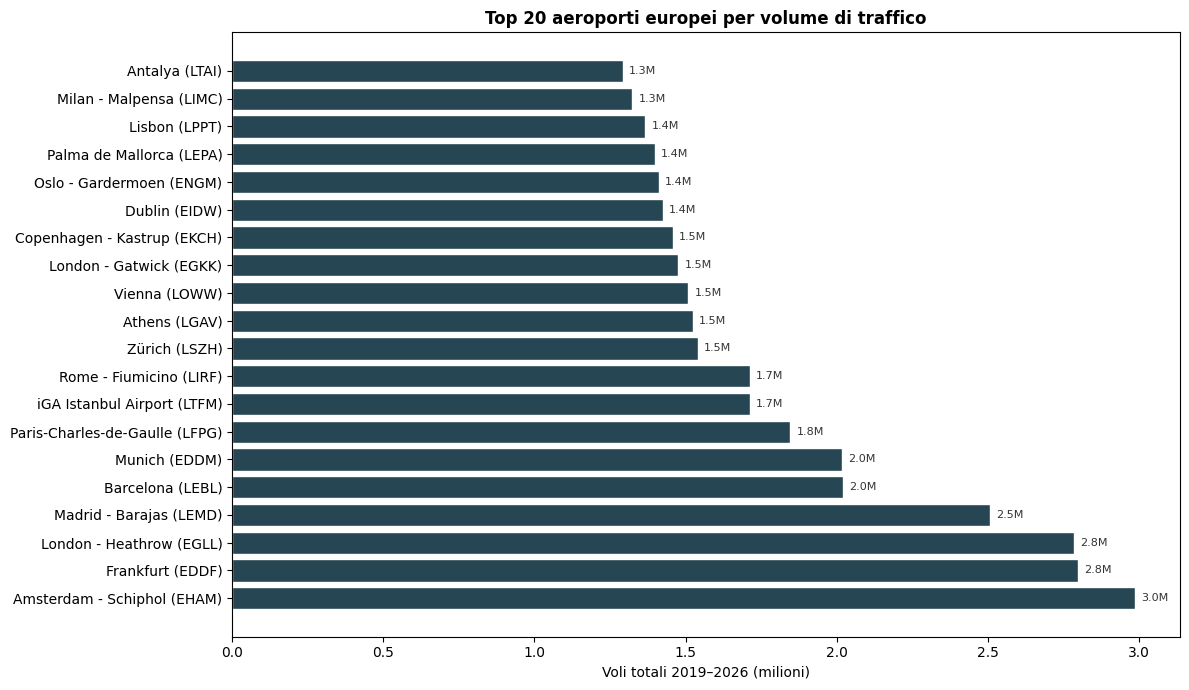

[Salvato] eda_apt_04_top20.png


In [4]:
# =============================================================================
# 6. TOP 20 AEROPORTI (totale voli 2019–2025)
# =============================================================================
top20 = (
    df.groupby(["APT_ICAO","APT_NAME"])["FLT_TOT_1"].sum()
    .reset_index()
    .sort_values("FLT_TOT_1", ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(12, 7))
labels = []
for _, row in top20.iterrows():
    labels.append(f"{row.APT_NAME} ({row.APT_ICAO})")
bars = ax.barh(labels, top20["FLT_TOT_1"] / 1e6,
               color="#264653", edgecolor="white")
#ax.invert_yaxis()
ax.set_xlabel("Voli totali 2019–2026 (milioni)")
ax.set_title("Top 20 aeroporti europei per volume di traffico", fontweight="bold")

for bar, val in zip(bars, top20["FLT_TOT_1"]):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f"{val/1e6:.1f}M", va="center", fontsize=8, color="#333")

#ax.axvline(x = average, color = 'red', linestyle= '--')
plt.tight_layout()
# plt.savefig("eda_apt_04_top20.png")
plt.show()
print("[Salvato] eda_apt_04_top20.png")

/var/folders/jy/4b2lm4512fj3l_x07qr_5v_r0000gn/T/ipykernel_10287/644850414.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax.get_xticklabels(), fontstyle='italic', fontsize=10)


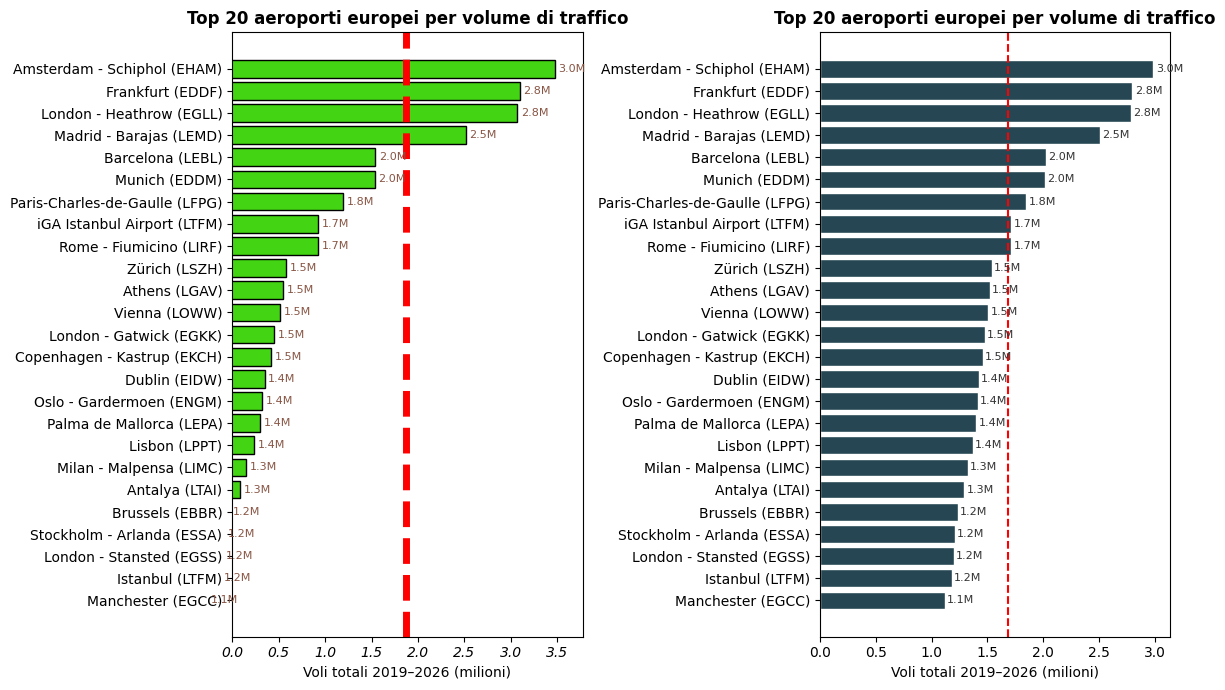

[Salvato] eda_apt_04_top20.png


In [5]:
top20 = (
    df.groupby(["APT_ICAO","APT_NAME"])["FLT_TOT_1"].sum()
    .reset_index()
    .sort_values("FLT_TOT_1", ascending=False)
    .head(25)
)
average = int(top20['FLT_TOT_1'].mean().round())/1e6
average = average * 13/10

a = top20["FLT_TOT_1"].sum()
b = a /5*2

fig, (ax1,ax2) = plt.subplots(1,2,figsize=(12, 7))
labels = []
for _, row in top20.iterrows():
    labels.append(f"{row.APT_NAME} ({row.APT_ICAO})")
bars = ax1.barh(labels, top20["FLT_TOT_1"] / 1e6,
               color="#43D413", edgecolor="black")
ax1.axvline(x = average, color = 'red', linestyle="--", linewidth=5)
ax1.invert_yaxis()
ax1.set_xlim(1.25, auto = False, emit = False)
ax1.set_xlabel("Voli totali 2019–2026 (milioni)")
ax1.set_title("Top 20 aeroporti europei per volume di traffico", fontweight="bold")
ax1.set_xticklabels(ax.get_xticklabels(), fontstyle='italic', fontsize=10)

for bar, val in zip(bars, top20["FLT_TOT_1"]):
    ax1.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f"{val/1e6:.1f}M", va="center", fontsize=8, color="#854")
    

average = int(top20['FLT_TOT_1'].mean().round())/1e6    
bars = ax2.barh(labels, top20["FLT_TOT_1"] / 1e6,
               color="#264653", edgecolor="white")
ax2.invert_yaxis()
ax2.set_xlabel("Voli totali 2019–2026 (milioni)")
ax2.set_title("Top 20 aeroporti europei per volume di traffico", fontweight="bold")

for bar, val in zip(bars, top20["FLT_TOT_1"]):
    ax2.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f"{val/1e6:.1f}M", va="center", fontsize=8, color="#333")

ax2.axvline(x = average, color = 'red', linestyle= '--')
plt.tight_layout()
# plt.savefig("eda_apt_04_top20.png")
plt.show()
print("[Salvato] eda_apt_04_top20.png")

In [6]:
top20
average = int(top20['FLT_TOT_1'].mean().round())/1e6
average
average = average * 10/10

In [7]:
b

np.float64(16818169.6)

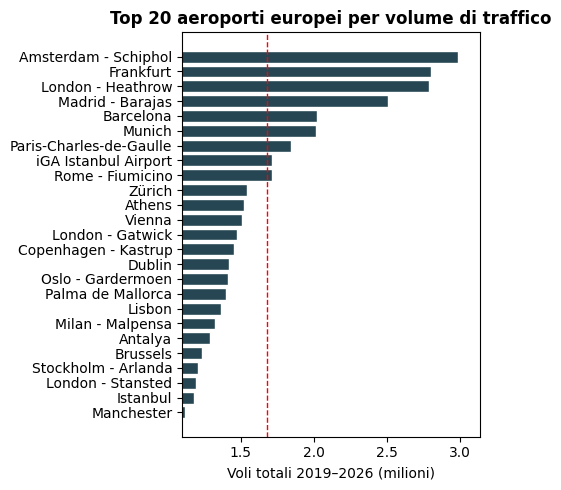

[Salvato] eda_apt_04_top20.png


In [13]:
top20 = (
    df.groupby(["APT_NAME"])["FLT_TOT_1"].sum()
    .reset_index()
    .sort_values("FLT_TOT_1", ascending=False)
    .head(25)
)

fig, ax = plt.subplots(figsize=(5, 5))
labels = []
for _, row in top20.iterrows():
    labels.append(f"{row.APT_NAME}")
bars = ax.barh(labels, top20["FLT_TOT_1"] / 1e6,
               color="#264653", edgecolor="white")
ax.invert_yaxis()
ax.set_xlabel("Voli totali 2019–2026 (milioni)")
ax.set_title("Top 20 aeroporti europei per volume di traffico", fontweight="bold")
#for bar, val in zip(bars, top20["FLT_TOT_1"]):
    #ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
     #       va="center", fontsize=8, color="#333")
ax.set_xlim(1.10)
ax.axvline(x = average, color = 'red', linestyle= '--', linewidth = 1)

plt.tight_layout()
# plt.savefig("eda_apt_04_top20.png")
plt.show()
print("[Salvato] eda_apt_04_top20.png")

In [ ]:
top20 = (
    df.groupby(["APT_NAME"])["FLT_TOT_1"].sum()
    .reset_index()
    .sort_values("FLT_TOT_1", ascending=False)
    .head(25)
)

fig, ax = plt.subplots(figsize=(5, 5))
labels = []
for _, row in top20.iterrows():
    labels.append(f"{row.APT_NAME}")
bars = ax.barh(labels, top20["FLT_TOT_1"] / 1e6,
               color="#264653", edgecolor="white")
ax.invert_yaxis()
ax.set_xlabel("Voli totali 2019–2026 (milioni)")
ax.set_title("Top 20 aeroporti europei per volume di traffico", fontweight="bold")
#for bar, val in zip(bars, top20["FLT_TOT_1"]):
    #ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
     #       va="center", fontsize=8, color="#333")
ax.set_xlim(1.10)
ax.axvline(x = average, color = 'red', linestyle= '--', linewidth = 1)

plt.tight_layout()
# plt.savefig("eda_apt_04_top20.png")
plt.show()
print("[Salvato] eda_apt_04_top20.png")

In [9]:
top20.to_csv('smart_df.csv')

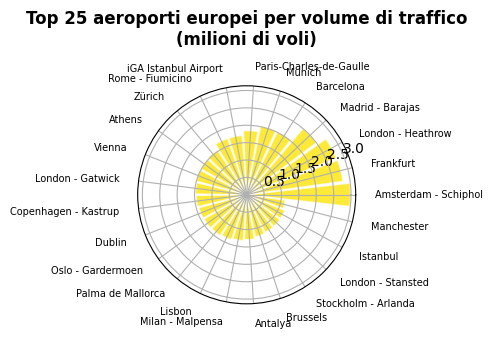

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = pd.read_csv("smart_df.csv")

N = len(df)
theta = np.linspace(0.0, 2 * np.pi, N, endpoint=False)
radii = df["FLT_TOT_1"].values / 1e6  # in milioni
width = 2 * np.pi / N * 0.9  # larghezza barre, con piccolo gap

colors = plt.cm.viridis(radii / radii.min())

fig, ax = plt.subplots(subplot_kw=dict(projection='polar'), figsize=(5, 5))
bars = ax.bar(theta, radii, width=width, bottom=0.0, color=colors, alpha=0.7, edgecolor="white")

# Etichette aeroporti
ax.set_xticks(theta)
ax.set_xticklabels(df["APT_NAME"], fontsize=7, rotation_mode="anchor")

# Ruota ogni etichetta per seguire il cerchio
for label, angle in zip(ax.get_xticklabels(), theta):
    angle_deg = np.degrees(angle)
    if 90 < angle_deg < 270:
        label.set_rotation(angle_deg + 180)
        label.set_ha("right")
    else:
        label.set_rotation(angle_deg)
        label.set_ha("left")
        bottom = 0.01  # prova valori diversi per esagerare


bars = ax.bar(theta, radii - bottom, width=width, bottom=bottom,
              color=colors, alpha=0.7, edgecolor="white")

ax.set_title("Top 25 aeroporti europei per volume di traffico\n(milioni di voli)", 
             fontweight="bold", pad=30)

plt.tight_layout()
plt.show()